In [1]:
!pip install ultralytics
!pip install easyocr
!pip install networkx
!pip install supervision
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 6.2 MB/s eta 0:00:00


In [2]:
!pip install git+https://github.com/facebookresearch/sam2.git

  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-8kar3dsy
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-8kar3dsy
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 5.3 MB/s eta 0:00:00
  Created wheel for SAM-2: filename=sam_2-1.0-cp312-cp312-linux_x86_64.whl size=183669 sha256=9b3d0e7afc5d568136b8110680502f89cefcbb97e4f38a00a12d387b4491cb59
  Stored in directory: /tmp/pip-ephem-wheel-cache-2db71cnl/wheels/25/a3/8a/abd69dc6a6926b5e75c24810afac36c7b49b5c0f8a100147d6
  Created wheel for iopath: filename=iopath-0.1.10-py3-non

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

import easyocr

import networkx as nx

from PIL import Image

import supervision as sv

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
import os

IMAGE_DIR = "/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images"
LABEL_DIR = "/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels"

print("Number of images :", len(os.listdir(IMAGE_DIR)))
print("Number of labels :", len(os.listdir(LABEL_DIR)))

print("\nSample images:")
print(os.listdir(IMAGE_DIR)[:5])

print("\nSample labels:")
print(os.listdir(LABEL_DIR)[:5])

Number of images : 3
Number of labels : 3

Sample images:
['val', 'test', 'train']

Sample labels:
['val', 'test', 'train']


In [5]:
import os

DATASET_PATH = "/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed"

TRAIN_IMAGES = os.path.join(DATASET_PATH, "images/train")
VAL_IMAGES   = os.path.join(DATASET_PATH, "images/val")
TEST_IMAGES  = os.path.join(DATASET_PATH, "images/test")

TRAIN_LABELS = os.path.join(DATASET_PATH, "labels/train")
VAL_LABELS   = os.path.join(DATASET_PATH, "labels/val")
TEST_LABELS  = os.path.join(DATASET_PATH, "labels/test")

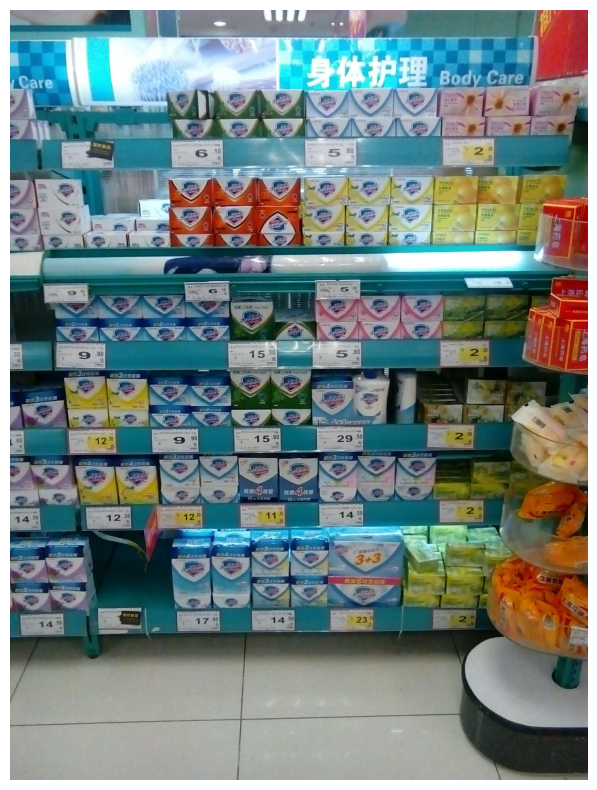

In [6]:
import cv2
import matplotlib.pyplot as plt

image_name = "val_69.jpg"

image_path = os.path.join(VAL_IMAGES, image_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,10))
plt.imshow(image)
plt.axis("off")
plt.show()

In [7]:
label_name = image_name.replace(".jpg", ".txt")

label_path = os.path.join(VAL_LABELS, label_name)

with open(label_path) as f:
    labels = f.readlines()

print(labels[:10])

['0 0.859375 0.413671875 0.071875 0.021875\n', '0 0.10338541666666666 0.7685546875 0.06510416666666667 0.046484375\n', '0 0.11458333333333333 0.42265625 0.07395833333333333 0.01796875\n', '0 0.19088541666666667 0.42109375 0.07447916666666667 0.01953125\n', '0 0.2674479166666667 0.4203125 0.07552083333333333 0.01796875\n', '0 0.34270833333333334 0.419921875 0.07395833333333333 0.01953125\n', '0 0.56484375 0.3828125 0.07135416666666666 0.0375\n', '0 0.5684895833333333 0.415625 0.0765625 0.02578125\n', '0 0.6411458333333333 0.3865234375 0.075 0.032421875\n', '0 0.7151041666666667 0.38515625 0.06770833333333333 0.0328125\n']


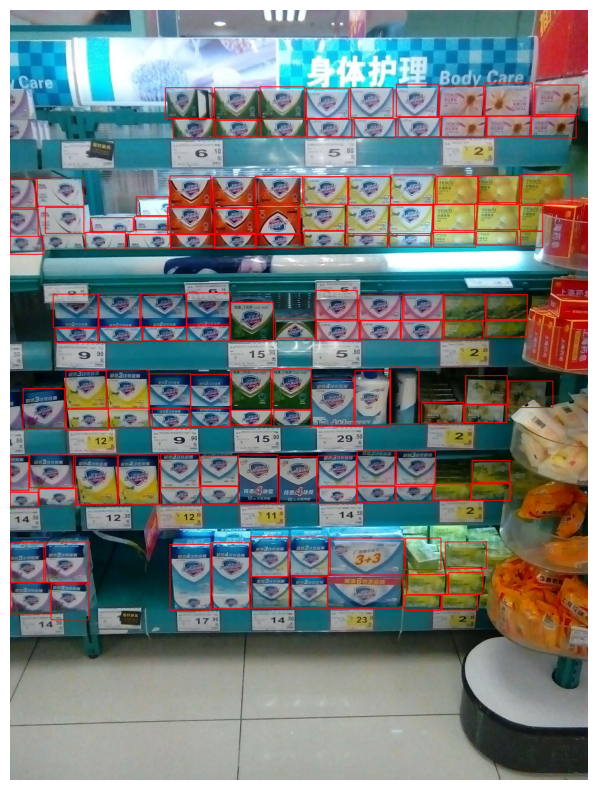

In [8]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image.shape[:2]

for line in labels:

    cls, xc, yc, bw, bh = map(float, line.split())

    xc *= w
    yc *= h
    bw *= w
    bh *= h

    x1 = int(xc - bw/2)
    y1 = int(yc - bh/2)
    x2 = int(xc + bw/2)
    y2 = int(yc + bh/2)

    cv2.rectangle(image, (x1,y1), (x2,y2), (255,0,0), 2)

plt.figure(figsize=(18,10))
plt.imshow(image)
plt.axis("off")
plt.show()

In [9]:
print("Training Images :", len(os.listdir(TRAIN_IMAGES)))
print("Validation Images :", len(os.listdir(VAL_IMAGES)))
print("Testing Images :", len(os.listdir(TEST_IMAGES)))

print()

print("Training Labels :", len(os.listdir(TRAIN_LABELS)))
print("Validation Labels :", len(os.listdir(VAL_LABELS)))
print("Testing Labels :", len(os.listdir(TEST_LABELS)))

Training Images : 8185
Validation Images : 584
Testing Images : 2920

Training Labels : 8185
Validation Labels : 584
Testing Labels : 2920


In [10]:
yaml_text = """
path: /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed

train: images/train
val: images/val
test: images/test

nc: 1

names:
  0: product
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_text)

print("data.yaml created successfully!")

data.yaml created successfully!


In [11]:
from ultralytics import YOLO
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [12]:
model = YOLO("yolo11m.pt")

In [13]:
import os

print("Train:", len(os.listdir(TRAIN_IMAGES)))
print("Validation:", len(os.listdir(VAL_IMAGES)))
print("Test:", len(os.listdir(TEST_IMAGES)))

Train: 8185
Validation: 584
Test: 2920


In [14]:
results = model.train(
    data="/kaggle/working/data.yaml",

    epochs=50,

    imgsz=640,

    batch=16,

    workers=4,

    device=0,

    optimizer="AdamW",

    lr0=0.001,

    patience=15,

    project="/kaggle/working",

    name="YOLOv11_SKU110K"
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv11_SKU110K, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overl

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

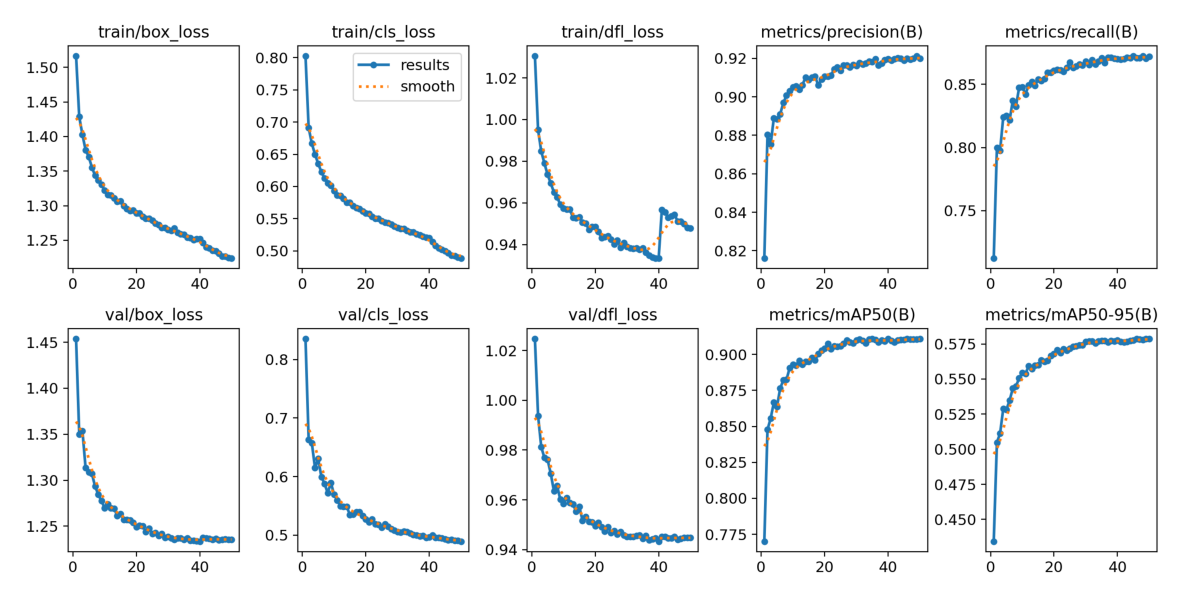

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/kaggle/working/YOLOv11_SKU110K/results.png")

plt.figure(figsize=(15,10))
plt.imshow(img)
plt.axis("off")

In [16]:
metrics = model.val(
    data="/kaggle/working/data.yaml"
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 810.4±355.6 MB/s, size: 1135.4 KB)
val: Scanning /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels/val... 584 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 584/584 304.8it/s 1.9s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 2% ──────────── 1/37 5.4s/it 1.6s<3:13WARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 5% ╸─────────── 2/37 5.8s/it 8.9s<3:24WARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50

In [ ]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/YOLOv11_SKU110K/weights/best.pt")

In [17]:
results = model.predict(
    source="/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/val/val_69.jpg",
    conf=0.25,
    save=False
)


image 1/1 /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/val/val_69.jpg: 640x480 143 products, 53.5ms
Speed: 3.0ms preprocess, 53.5ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)


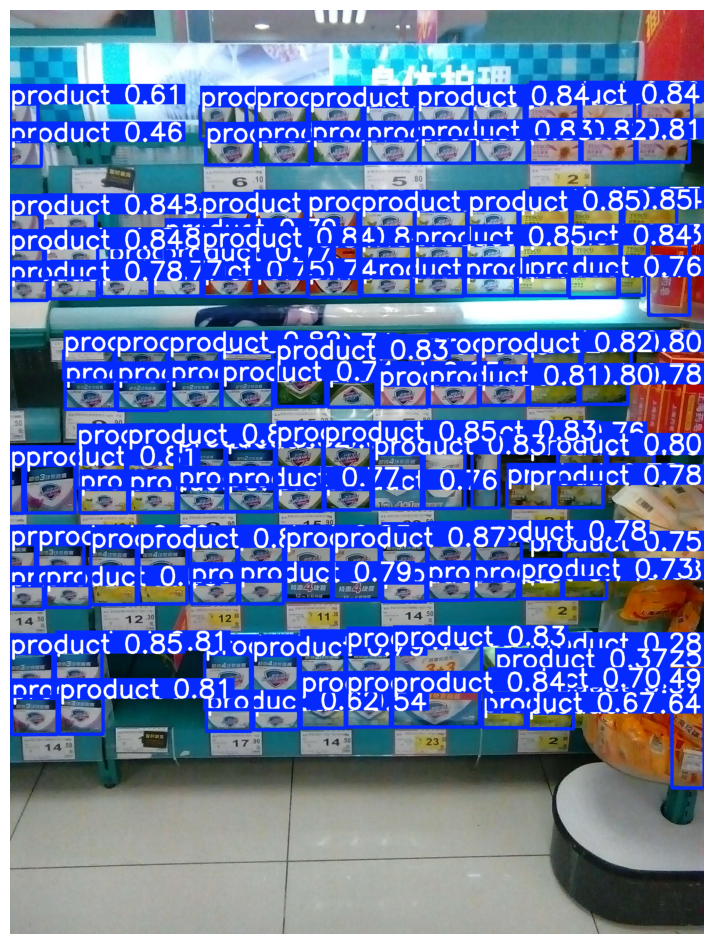

In [18]:
import matplotlib.pyplot as plt

result = results[0].plot()

plt.figure(figsize=(18,12))
plt.imshow(result[..., ::-1])
plt.axis("off")
plt.show()

In [19]:
boxes = results[0].boxes.xyxy.cpu().numpy()

scores = results[0].boxes.conf.cpu().numpy()

classes = results[0].boxes.cls.cpu().numpy()

In [20]:
import pandas as pd

detections = pd.DataFrame({
    "x1": boxes[:,0],
    "y1": boxes[:,1],
    "x2": boxes[:,2],
    "y2": boxes[:,3],
    "confidence": scores,
    "class": classes
})

detections.head()

,x1,y1,x2,y2,confidence,class
0,894.128784,1486.801514,1021.858032,1634.287842,0.868620,0.0
1,762.195312,1485.070801,889.166016,1634.545410,0.859409,0.0
2,869.425171,1193.676392,998.467407,1324.225220,0.853192,0.0
3,1267.123413,554.625488,1405.457397,644.438721,0.850842,0.0
4,0.230850,1782.064209,118.008598,1901.344482,0.849900,0.0


In [21]:
import cv2

image = cv2.imread("/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/val/val_69.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

crops = []

for i,row in detections.iterrows():

    x1=int(row.x1)
    y1=int(row.y1)
    x2=int(row.x2)
    y2=int(row.y2)

    crop=image[y1:y2,x1:x2]

    crops.append(crop)

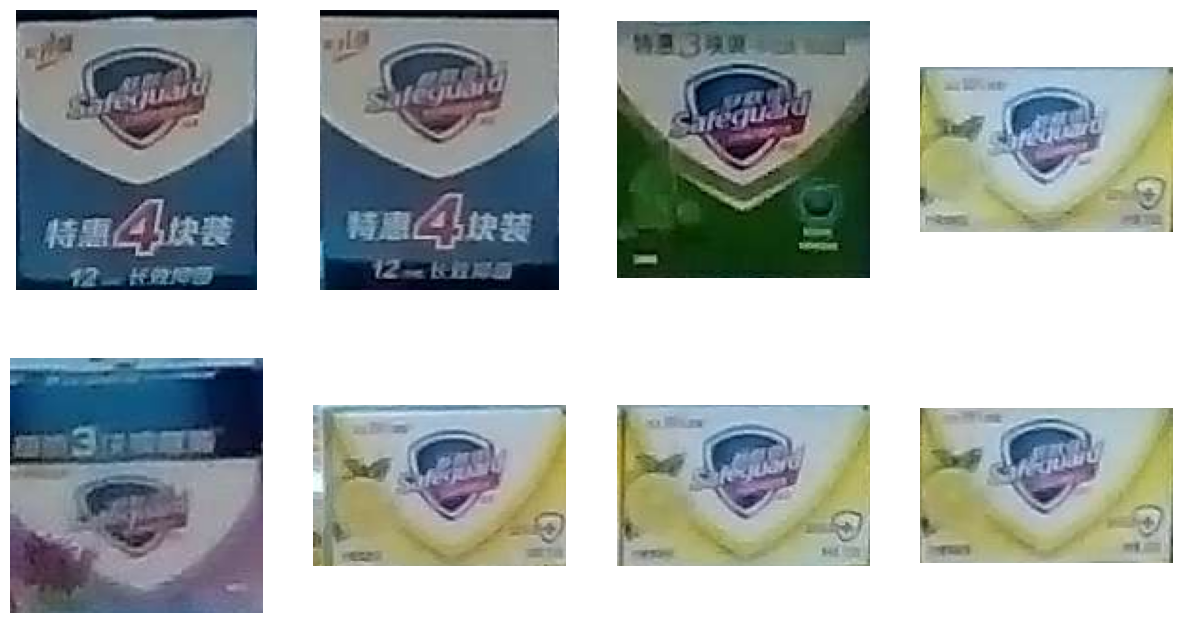

In [22]:
plt.figure(figsize=(15,8))

for i in range(min(8,len(crops))):

    plt.subplot(2,4,i+1)
    plt.imshow(crops[i])
    plt.axis("off")

plt.show()

In [47]:
!pip install -q paddleocr
!pip install -q paddlepaddle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 28.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 97.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 94.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.8/417.8 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [48]:
from paddleocr import PaddleOCR

In [49]:
ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    lang="en"
)

Creating model: ('PP-OCRv6_medium_det', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv6_medium_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_det`.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

In [54]:
import easyocr

# Initialize reader once
reader = easyocr.Reader(['en'])

# Run on your crop directly
results = reader.readtext(crops[0])
for bbox, text, prob in results:
    print(f"Detected: {text} (Confidence: {prob:.2f})")

Detected: "MaGnr (Confidence: 0.05)
Detected: Kale (Confidence: 0.03)


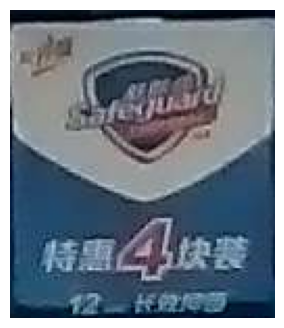

In [55]:
plt.figure(figsize=(4,4))
plt.imshow(crops[0])
plt.axis("off")
plt.show()

In [58]:
def extract_text(ocr_result):
    words = []
    # If the result is a list of text detection elements
    for item in ocr_result:
        # Depending on the OCR library, the text string is usually at index 1 (e.g., [bbox, text, prob])
        if isinstance(item, (list, tuple)) and len(item) >= 2:
            words.append(str(item[1]))
        elif isinstance(item, str):
            words.append(item)
    return " ".join(words)

In [59]:
text = extract_text(result)

print(text)

In [61]:
reader = easyocr.Reader(['en'])

product_labels = []

for i, crop in enumerate(crops):
    # Run EasyOCR directly on the numpy crop array
    results = reader.readtext(crop)
    
    # Extract just the text strings where confidence is decent
    texts = [text for (_, text, prob) in results if prob > 0.2]
    
    # Join detected words for this crop
    combined_text = " ".join(texts)
    product_labels.append(combined_text)

print(product_labels[:10])

['', '', '', '', '', '', '', '', '', '']


In [62]:
import pandas as pd

product_df = detections.copy()

product_df["label"] = product_labels

product_df.head()

,x1,y1,x2,y2,confidence,class,label
0,894.128784,1486.801514,1021.858032,1634.287842,0.868620,0.0,
1,762.195312,1485.070801,889.166016,1634.545410,0.859409,0.0,
2,869.425171,1193.676392,998.467407,1324.225220,0.853192,0.0,
3,1267.123413,554.625488,1405.457397,644.438721,0.850842,0.0,
4,0.230850,1782.064209,118.008598,1901.344482,0.849900,0.0,


In [63]:
product_df["center_x"] = (product_df["x1"] + product_df["x2"]) / 2
product_df["center_y"] = (product_df["y1"] + product_df["y2"]) / 2

In [64]:
product_df.head()

,x1,y1,x2,y2,confidence,class,label,center_x,center_y
0,894.128784,1486.801514,1021.858032,1634.287842,0.868620,0.0,,957.993408,1560.544678
1,762.195312,1485.070801,889.166016,1634.545410,0.859409,0.0,,825.680664,1559.808105
2,869.425171,1193.676392,998.467407,1324.225220,0.853192,0.0,,933.946289,1258.950806
3,1267.123413,554.625488,1405.457397,644.438721,0.850842,0.0,,1336.290405,599.532104
4,0.230850,1782.064209,118.008598,1901.344482,0.849900,0.0,,59.119724,1841.704346


In [65]:
from sklearn.cluster import KMeans

In [66]:
NUM_ROWS = 3

In [67]:
kmeans = KMeans(
    n_clusters=NUM_ROWS,
    random_state=42,
    n_init=10
)

product_df["row"] = kmeans.fit_predict(
    product_df[["center_y"]]
)

In [68]:
row_order = (
    product_df.groupby("row")["center_y"]
    .mean()
    .sort_values()
    .index
)

mapping = {old: new for new, old in enumerate(row_order)}

product_df["row"] = product_df["row"].map(mapping)

In [69]:
product_df[["label", "row"]].head()

,label,row
0,,2
1,,2
2,,1
3,,0
4,,2


In [70]:
product_df = product_df.sort_values(
    ["row", "center_x"]
).reset_index(drop=True)

In [71]:
product_df["column"] = (
    product_df.groupby("row")
              .cumcount()
)

In [72]:
import networkx as nx

G = nx.Graph()

In [73]:
for idx, row in product_df.iterrows():

    G.add_node(
        idx,

        label=row["label"],

        x=row["center_x"],
        y=row["center_y"],

        row=row["row"],
        column=row["column"],

        confidence=row["confidence"]
    )

In [74]:
for shelf in product_df["row"].unique():

    shelf_products = (
        product_df[product_df["row"] == shelf]
        .sort_values("column")
    )

    indices = shelf_products.index.tolist()

    for i in range(len(indices) - 1):

        G.add_edge(
            indices[i],
            indices[i + 1],
            relation="right_of"
        )

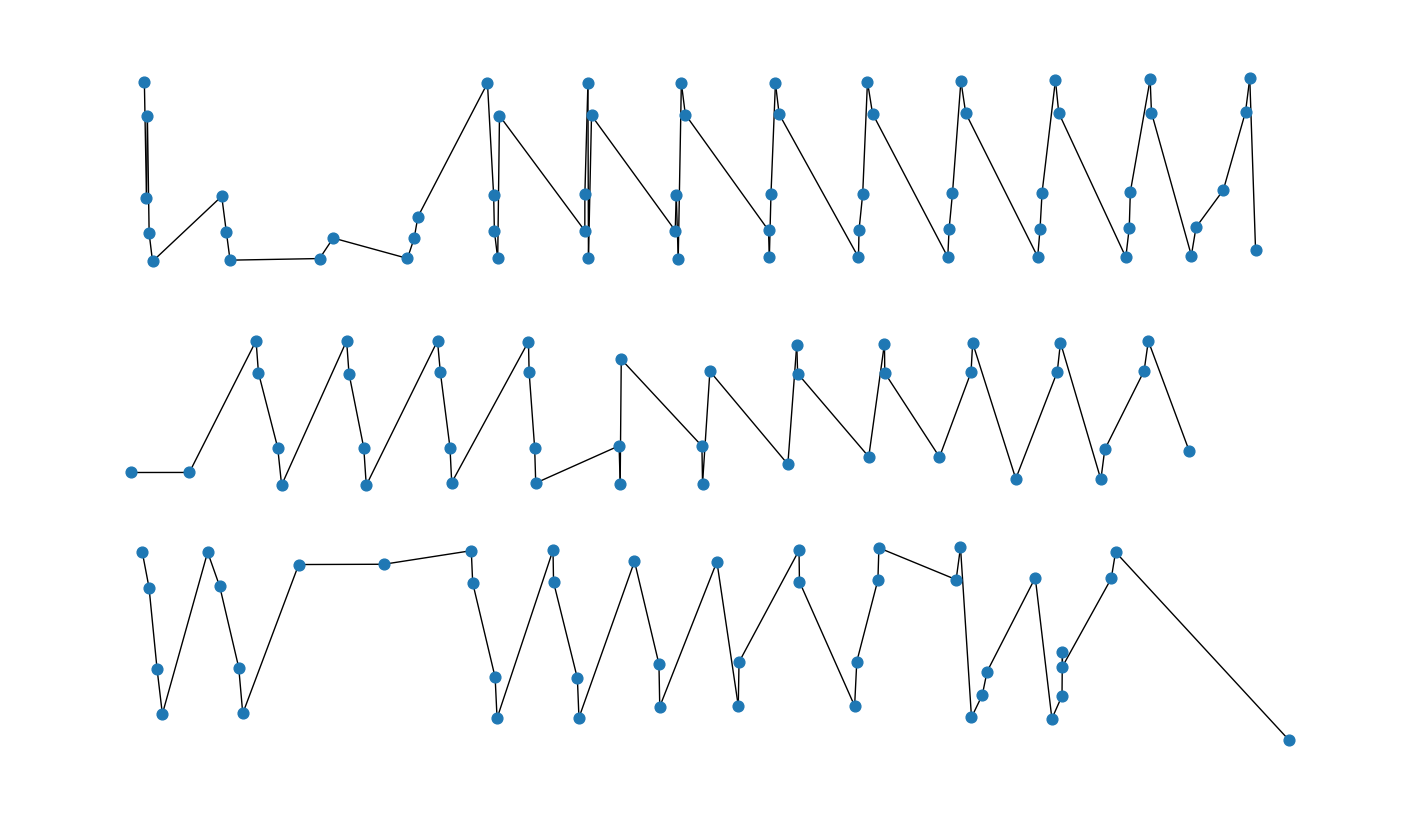

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

pos = {}

for node in G.nodes():

    pos[node] = (
        G.nodes[node]["x"],
        -G.nodes[node]["y"]  # invert y for display
    )

nx.draw(
    G,
    pos,
    with_labels=False,
    node_size=60
)

plt.show()

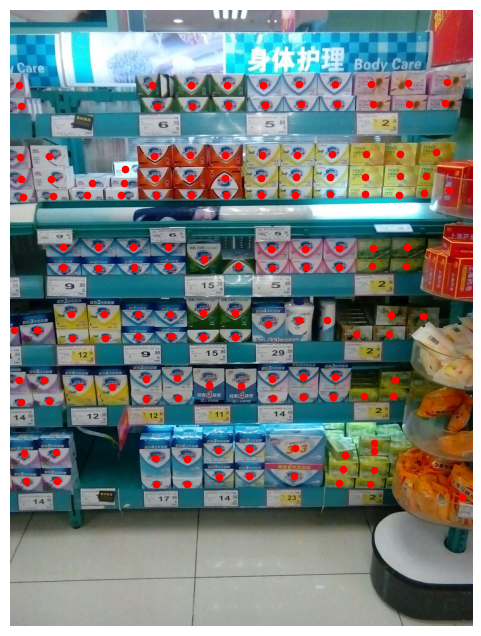

In [76]:
plt.figure(figsize=(15,8))
plt.imshow(image)

plt.scatter(
    product_df["center_x"],
    product_df["center_y"],
    c="red",
    s=20
)

plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(1919.5), np.float64(2559.5), np.float64(-0.5))

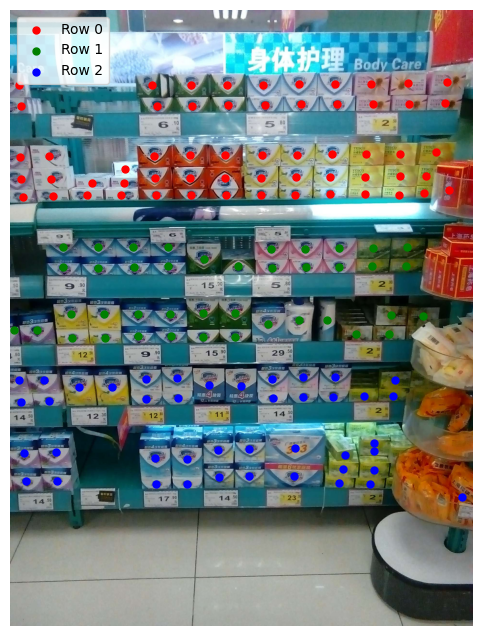

In [77]:
colors = ["red", "green", "blue", "orange", "purple"]

plt.figure(figsize=(16,8))
plt.imshow(image)

for row in range(NUM_ROWS):

    temp = product_df[product_df.row == row]

    plt.scatter(
        temp.center_x,
        temp.center_y,
        color=colors[row],
        s=25,
        label=f"Row {row}"
    )

plt.legend()
plt.axis("off")

(np.float64(-0.5), np.float64(1919.5), np.float64(2559.5), np.float64(-0.5))

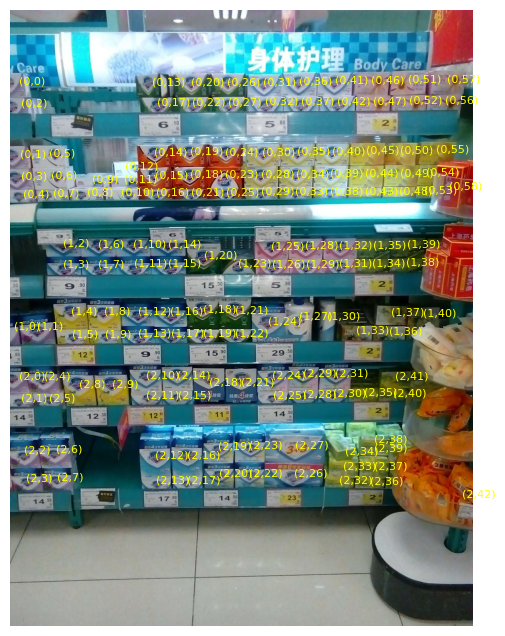

In [78]:
plt.figure(figsize=(16,8))
plt.imshow(image)

for _, r in product_df.iterrows():

    plt.text(
        r.center_x,
        r.center_y,
        f"({r.row},{r.column})",
        color="yellow",
        fontsize=8
    )

plt.axis("off")

(np.float64(-0.5), np.float64(1919.5), np.float64(2559.5), np.float64(-0.5))

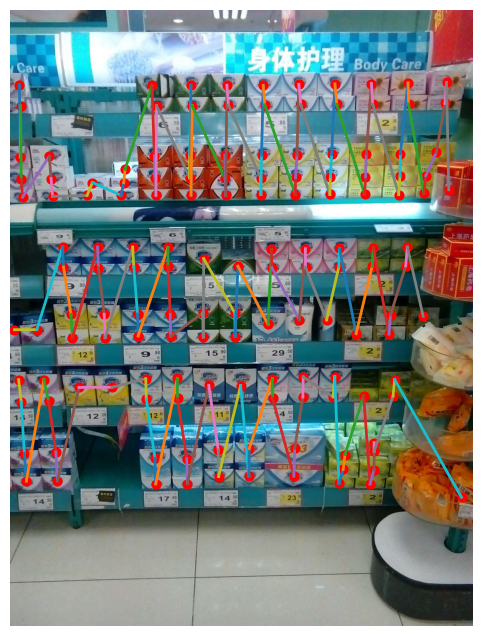

In [79]:
plt.figure(figsize=(16,8))
plt.imshow(image)

for _, r in product_df.iterrows():

    plt.scatter(
        r.center_x,
        r.center_y,
        color="red",
        s=40
    )

for u, v in G.edges():

    x = [
        G.nodes[u]["x"],
        G.nodes[v]["x"]
    ]

    y = [
        G.nodes[u]["y"],
        G.nodes[v]["y"]
    ]

    plt.plot(x, y, linewidth=2)

plt.axis("off")

In [80]:
print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

degrees = [d for _, d in G.degree()]
print("Average Degree:", sum(degrees)/len(degrees))

Number of Nodes: 143
Number of Edges: 140
Average Degree: 1.9580419580419581


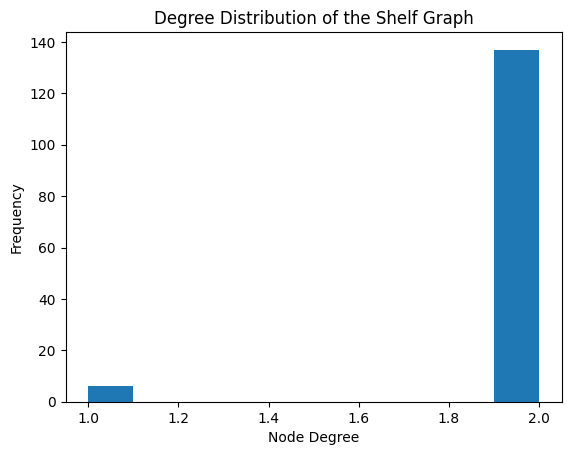

In [81]:
import matplotlib.pyplot as plt

plt.hist(degrees, bins=10)
plt.xlabel("Node Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution of the Shelf Graph")
plt.show()

KeyError: 'center'

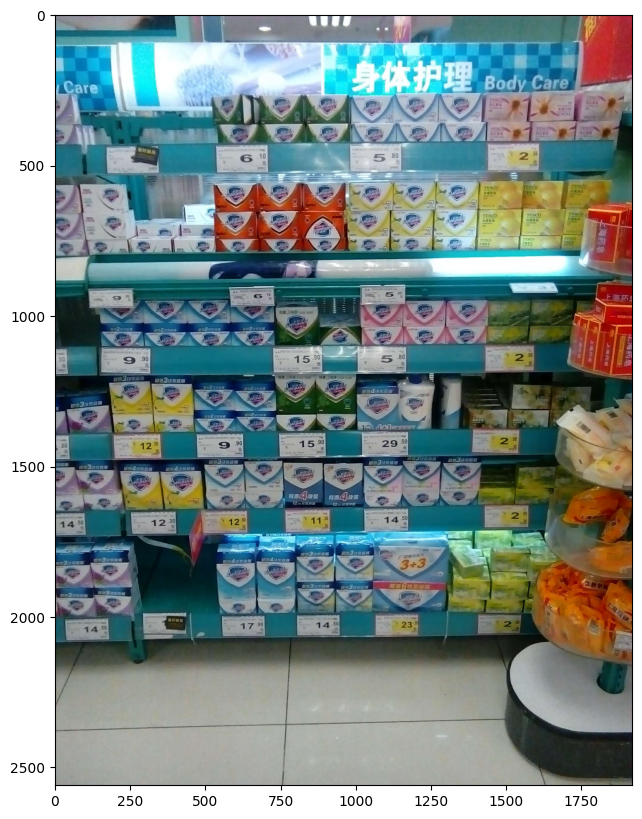

In [82]:
plt.figure(figsize=(16,10))
plt.imshow(image)

for node in G.nodes():
    x, y = G.nodes[node]["center"]
    label = G.nodes[node]["label"]

    plt.scatter(x, y, color="red", s=30)
    plt.text(x + 5, y, label, fontsize=6, color="yellow")

plt.axis("off")
plt.show()